# TESI Master Data Science UNICUSANO

Il link al drive con altro materiale: https://drive.google.com/drive/folders/1rvWc7hgexlplYTKFxeiwVRS5dZ1NV9Vw?usp=share_link

# Preparazione dell'ambiente

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn import svm, tree
from sklearn.metrics import *


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/materiale-progetto12/

/content/drive/MyDrive/materiale-progetto12


In [ ]:
adult_train = pd.read_csv("adult.train.csv", index_col=False)

In [ ]:
adult_test = pd.read_csv("adult.test.csv", index_col=False)

# Fase 1

### a) Preview del dataset

---

In primis eseguo il codice per visualizzare una preview dei dati che andrò ad analizzare, con un breve appendice sulla larghezza di entrambi i dataset (quindi preview con numero di righe e di colonne sia per il training che per il test)

In [ ]:
righeTR = adult_train.shape[0]
colonneTR = adult_train.shape[1]
print("Numero righe dati di training: ", righeTR)
print("Numero colonne dati di training: ", colonneTR)
adult_train.head(10)

Numero righe dati di training:  32561
Numero colonne dati di training:  15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


In [ ]:
righeTE = adult_test.shape[0]
colonneTE = adult_test.shape[1]
print("Numero righe dati di test: ", righeTE)
print("Numero colonne dati di test: ", colonneTE)
adult_test.head(10)

Numero righe dati di test:  16281
Numero colonne dati di test:  15


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


* Il training dataset si compone di 32561 righe e 15 colonne. 15 colonne anche per il dataset di test, che però si differenzia per il totale di righe: 16281, la metà circa del precedente. Ipotizzando che si trattasse di un dataset unico in precedenza, potrebbe essere stato scomposto in due terzi dei dati a fare da training e un terzo per il test.

* Come visibile dalle preview, le strutture dei due dataset sono identiche ma in quello di test si notano dei **valori sconosciuti**, ovvero un punto di domanda, tra gli attributi *workclass e occupation*.

* Sarà utile capire se tali errori sono presenti anche nei dati di training ed eventualmente correggerli o escluderli in fase di modellazione.



## b) Informazioni generali

---
Vediamo ulteriori informazioni generali sulle tabelle e sulle variabili, cercando di scoprire se oltre a valori sconosciuti vi sono anche valori nulli:


In [ ]:
adult_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
adult_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16281 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             16281 non-null  int64 
 1   workclass       16281 non-null  object
 2   fnlwgt          16281 non-null  int64 
 3   education       16281 non-null  object
 4   education-num   16281 non-null  int64 
 5   marital-status  16281 non-null  object
 6   occupation      16281 non-null  object
 7   relationship    16281 non-null  object
 8   race            16281 non-null  object
 9   sex             16281 non-null  object
 10  capital-gain    16281 non-null  int64 
 11  capital-loss    16281 non-null  int64 
 12  hours-per-week  16281 non-null  int64 
 13  native-country  16281 non-null  object
 14  income          16281 non-null  object
dtypes: int64(6), object(9)
memory usage: 1.9+ MB


* Eseguendo il codice si trova innanzitutto conferma della quantità di righe e di colonne 
* Sorprendentemente si nota che non vi sono valori nulli. 
* Ci sono 6 variabili numeriche che contengono valori interi, mentre per le restanti 9 si tratta di attributi testuali, i cui valori corrispondono a stringhe di testo.

## c) Bilanciamento dataframe e statistica descrittiva

---

Vediamo dunque se i due dataset sono bilanciati, visionando alcune metriche di statistica descrittiva sulle variabili numeriche:

In [ ]:
adult_train[["age","education-num","capital-gain","capital-loss","hours-per-week"]].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,10.080679,1077.648844,87.303830,40.437456
std,13.640433,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
adult_test[["age","education-num","capital-gain","capital-loss","hours-per-week"]].describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,16281.000000,16281.000000,16281.000000,16281.000000,16281.000000
mean,38.767459,10.072907,1081.905104,87.899269,40.392236
std,13.849187,2.567545,7583.935968,403.105286,12.479332
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,3770.000000,99.000000


I due dataframe risultano omogenei, le statistiche sono infatti piuttosto simili. Nel dettaglio: 
* L'età media è di circa 38 anni e mezzo, il minimo è 17 anni mentre il massimo è 90. 
* La media delle ore lavorate a settimana si attesta a 40, ovvero un classico orario full time.

* Per quanto riguarda i dati sul capitale, si osserva l'assoluta differenza tra la media e la mediana visibile nel quartile centrale: ciò significa che sono presenti degli evidenti outliers. Questa variabile potrebbe essere poco significativa ai fini dell'analisi?

* Anche in relazione alle ore lavorate si possono osservare degli outliers poco credibili sul valore minimo (1 ora lavorata a settimana) e sul valore massimo (99 ore lavorate a settimana).

Assodata l'omogeneità tra dati di test e quelli di training, mi concentro esclusivamente su quest'ultimi. Le seguenti 5 osservazioni sono eseguite sulle variabili che ritengo possano essere più importanti e sulle quali agganciarsi la fase 2 di data-viz.

## d) *Focus/dettagli*

Come si distribuisce la popolazione in base al sesso? Qual é l'età media di 
questi?

In [ ]:
adult_train["sex"].value_counts()

Male      21790
Female    10771
Name: sex, dtype: int64

In [ ]:
adult_train.groupby(adult_train["sex"])["age"].mean()

sex
Female    36.858230
Male      39.433547
Name: age, dtype: float64

* Il sesso predominante del dataframe è quello maschile, che rappresenta circa due terzi della popolazione totale. 
* L'età media generale, come visto in precedenza, è di 38.7 anni: come visibile dal codice sopra, la media per le donne è vicina ma sono mediamente più giovani (36.8), mentre gli uomini sono mediamente più anziani (39.4).

---



La metrica da predire: il reddito. Vediamo come si distribuisce la popolazione totale tra le due categorie di *income*

In [ ]:
adult_train["income"].value_counts()

<=50K    24720
>50K      7841
Name: income, dtype: int64

* Le categorie di reddito sono solo due: meno di 50k o più di 50k. 
* Come prevedibile, la maggiorparte dei soggetti non supera la soglia dei 50k e sono più del triplo di coloro che la superano.

---



Qual è l'età media di chi ha reddito maggiore di 50k? E l'età media di chi invece guadagna meno di 50k?

In [ ]:
adult_train.groupby(adult_train["income"])["age"].mean()

income
<=50K    36.783738
>50K     44.249841
Name: age, dtype: float64

* L'età media del primo gruppo si attesta a 36.7 anni ed è inferiore di quasi 8 punti rispetto al gruppo di chi guadagna più di 50k, probabilmente il reddito si alza in quella fascia di età visto che la carriera professionale dovrebbe aver raggiunto quasi il suo picco.

---



Ore lavorate per professione di coloro che guadagnano +50k

In [ ]:
rich = adult_train[adult_train["income"] == ">50K"]

print(rich.groupby(['occupation'])['hours-per-week'].mean())

occupation
?                    36.146597
Adm-clerical         40.942801
Armed-Forces         40.000000
Craft-repair         44.682454
Exec-managerial      47.308435
Farming-fishing      54.208696
Handlers-cleaners    42.732558
Machine-op-inspct    43.364000
Other-service        43.051095
Priv-house-serv      35.000000
Prof-specialty       45.179666
Protective-serv      45.549763
Sales                47.431333
Tech-support         41.427562
Transport-moving     48.771875
Name: hours-per-week, dtype: float64


* In questo caso si nota innanzitutto che, per avere un reddito maggiore, le ore lavorate corrispondono di solito ad almeno un full time per week.
 
* Interessante anche che alcuni tipi di lavoro solitamente ritenuti più umili rientrino nel gruppo dei +50k (*cleaners, private house services, farm/fish o clerical)*, anche se probabilmente pochi

---



Sempre sulle professioni, vediamo cosa accade testando l'altra variabile lavorativa più generica: *workclass*

In [ ]:
rich = adult_train[adult_train["income"] == ">50K"]

print(rich.groupby(['workclass'])['hours-per-week'].mean())

workclass
?                   36.146597
Federal-gov         43.420485
Local-gov           43.956240
Private             45.500907
Self-emp-inc        50.154341
Self-emp-not-inc    46.691989
State-gov           44.186969
Name: hours-per-week, dtype: float64


L'unico parametro notabile è l'orario lavorativo maggiore per gli imprenditori. Nella fase 2-3 si analizza anche il parametro collegato, *occupation*, per capire se potrebbe rivelarsi più utile di *workclass*

---



# Fase 2

---
Segue la parte di visualizzazione, in cui si mostrano i grafici basati su quanto indicato nel titolo della relativa sotto-sezione.

---





## Istruzione e ore lavorate per reddito

---

Scatter plot per vedere la correlazione tra livello di educazione e ore lavorate a settimana, con distinzione tra le due tipologie di reddito offerte dal dataset.

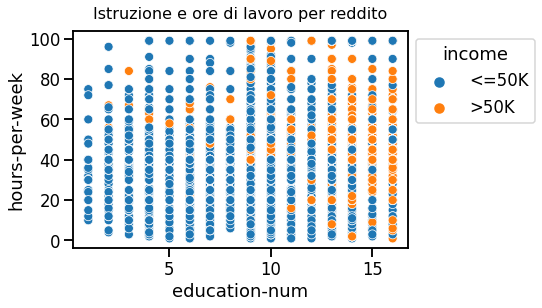

In [ ]:
edu_hxw = sns.scatterplot(x="education-num", y="hours-per-week", data=adult_train, hue="income")
plt.title('Istruzione e ore di lavoro per reddito', fontdict={'fontsize':16}, pad=12)
sns.move_legend(edu_hxw, "upper left", bbox_to_anchor=(1, 1)) 
plt.show()

* Dal grafico è evidente che la categoria di persone che supera la soglia dei 50k aumenta con l'aumentare del grado di istruzione. 
* Più interessante è il fatto che negli ultimi gradi di istruzione (14-16), gli "arancioni" siano distruibiti quasi equamente tra il numero di ore lavorate. 


## Il capitale

---


Al punto 1c ho ipotizzato che la variabile del capitale investito fosse poco significativa, causa eterogeneità dei dati. Ma coloro con plusvalenza positiva sono per caso quelli precedentemente collocati tra i gradi alti di istruzione che lavorano poco? Quanto incide un capital gain > 0 sul fatto di essere nel gruppo dei +50k?

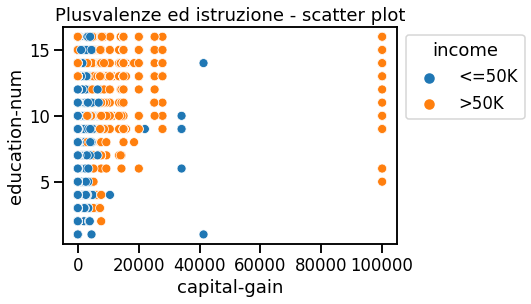

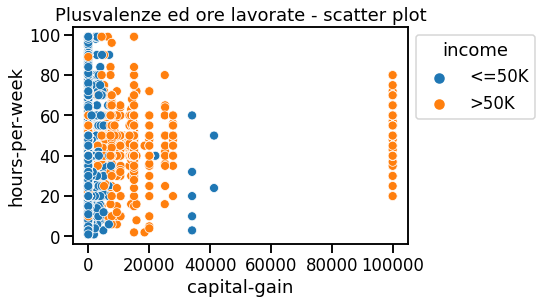

In [ ]:
cap_edu = sns.scatterplot(x="capital-gain", y="education-num", data=adult_train, hue="income")
plt.title('Plusvalenze ed istruzione - scatter plot')
sns.move_legend(cap_edu, "upper left", bbox_to_anchor=(1, 1)) 
plt.show()

cap_hxw = sns.scatterplot(x="capital-gain", y="hours-per-week", data=adult_train, hue="income")
plt.title('Plusvalenze ed ore lavorate - scatter plot')
sns.move_legend(cap_hxw, "upper left", bbox_to_anchor=(1, 1)) 
plt.show()

*   Il primo grafico mostra la relazione tra grado di istruzione e investimenti positivi, spacchettando il dato anche tra i due gruppi di reddito (+/-50k). Si può affermare che tendenzialmente più il grado di istruzione è alto, più alta è la propensione ad investire capitale e più è probabile essere nel gruppo +50k di reddito. Gli outliers presenti, ovvero coloro che hanno guadagnato 100k da investimento, sono nel gruppo di reddito +50k. 
*   Dal secondo grafico, in cui si confrontano le ore lavorate settimanalmente con la rendita da investimento e il gruppo di reddito, emerge che quasi tutti coloro che hanno rendita da investimento si collocano tra i +50k. Inoltre risulta evidente che la maggiorparte degli appartenenti al gruppo -50k non ha avuto guadagni da investimento (o sono comunque limitati, a parte le eccezioni visibili sui 40k). 

*Da questa analisi sembra che, contrariamente a quanto evidenziato nella fase 1, la variabile capital-gain sia più rilevante di quanto inizialmente pensato. La variabile hours-per-week si conferma, finora, non propriamente rilevante.*

---



## Occupazione e professione

---

Analisi grafica dei dati sulla professionalità. 

Disponiamo di due variabili: una più generica, *workclass*, e una che entra più nel dettaglio del lavoro svolto, *occupation*

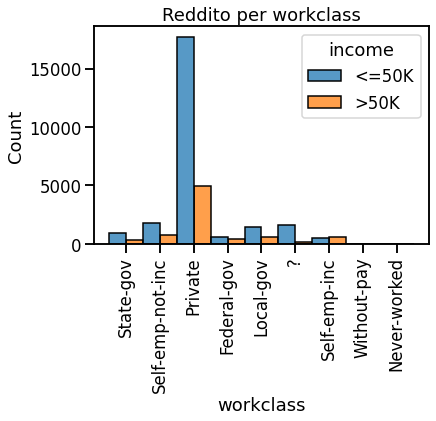

In [ ]:
sns.set_context("talk")
sns.histplot(x="workclass", hue="income", data=adult_train, multiple="dodge")
plt.xticks(rotation = 90)
plt.title('Reddito per workclass')
plt.show()

Dal grafico emerge che:

*   la categoria di lavoro più diffusa è quella nel **settore privato**, in cui il 20% circa (ad occhio) guadagna più di 50k
*   gli **imprenditori self-emp-incorporated**  sono la categoria con maggiore probabilità di guadagnare più di 50k l'anno (ovvero più della metà di questi, come visibile, sono nel gruppo +50k)
* anche il lavoro negli **enti federali** procura una buona probabilità di superare i 50k (ma meno del 50% di questi lo superano)




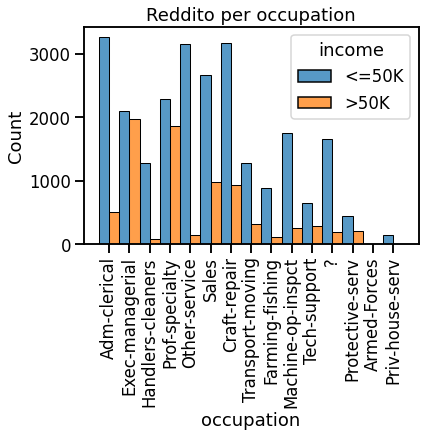

In [ ]:
sns.histplot(x="occupation", hue="income", data=adult_train, multiple="dodge")
plt.xticks(rotation = 90)
sns.set_context("talk")
plt.title('Reddito per occupation')
plt.show()

Entrando nello specifico sulle occupazione risulta che:
* la professione *Executive Manager* è quella con la percentuale più alta di persone che guadagnano di più (quasi la metà degli occupati del settore nel gruppo 50k)
* la seconda professione con più persone con reddito >50k è *Prof-Specialty*
* la categoria *Other Service* raggrupa parecchie persona, 3000 persone, ma la quantità di questi che superano la soglia 50k è particolarmente limitata (visibilmente la peggiore)
* anche le categorie *Sales* e *Craft-repair* sono molto diffuse e vi è una rilevante mole di lavoratori (mille per categoria) che supera 50k di reddito. 

---




## Stato civile e relazioni

---

In questo punto si analizzano le variabili *relationship* e *marital status* per capire la loro correlazione con *income*

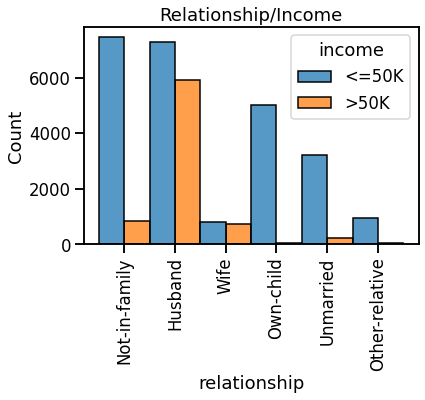

In [ ]:
sns.histplot(x="relationship", hue="income", data=adult_train, multiple="dodge")
plt.xticks(rotation = 90)
sns.set_context("talk")
plt.title('Relationship/Income')
plt.show()

*   dall'istogramma appare chiaro che i mariti sono tra coloro che guadagnano di più. Sono 6mila infatti i mariti che guadagnano più di 50k e sono quantitativamente non lontani dai mariti <50k
*   da evidenziare sicuramente che le mogli, anche se meno presenti nel dataset, hanno la più alta probabilità di superare i 50k. I due gruppi reddituali di mogli sono infatti quasi pari.



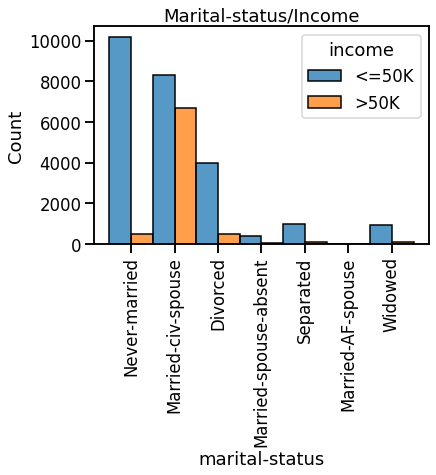

In [ ]:
sns.histplot(x="marital-status", hue="income", data=adult_train, multiple="dodge")
plt.xticks(rotation = 90)
sns.set_context("talk")
plt.title('Marital-status/Income')
plt.show()

* Appare ancora più chiaro, osservando questo secondo grafico, che **il matrimonio conviene**: difatti l'unica categoria con una rilevante predisposizione ad avere reddito >50k è quella degli sposi civili (circa 6 su 14)

## Provenienza geografica ed etnia

---

Analisi dei dati sulla razza e sul paese natale della popolazione. 

Come si distribuiscono? Quanto incidono tali variabili sulla determinazione della fascia di reddito?

In [ ]:
rich = adult_train[adult_train["income"] == ">50K"]
not_rich = adult_train[adult_train["income"] == "<=50K"]

print("conteggio delle persone che guadagnano <50k per razza")
print(rich.groupby(['race'])['race'].count())

print("conteggio delle persone che guadagnano >50k per razza")
print(not_rich.groupby(['race'])['race'].count())

conteggio delle persone che guadagnano <50k per razza
race
Amer-Indian-Eskimo      36
Asian-Pac-Islander     276
Black                  387
Other                   25
White                 7117
Name: race, dtype: int64
conteggio delle persone che guadagnano >50k per razza
race
Amer-Indian-Eskimo      275
Asian-Pac-Islander      763
Black                  2737
Other                   246
White                 20699
Name: race, dtype: int64


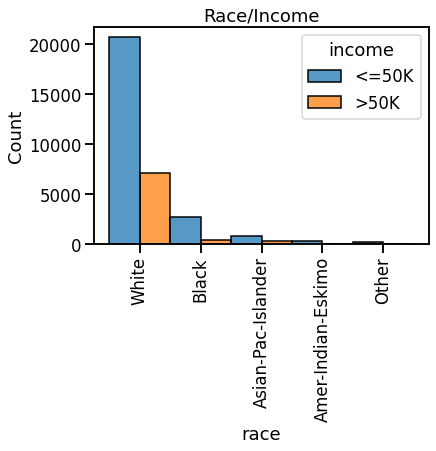

In [ ]:
sns.histplot(x="race", hue="income", data=adult_train, multiple="dodge")
plt.xticks(rotation = 90)
sns.set_context("talk")
plt.title('Race/Income')
plt.show()

* In prevalenza il dataframe si compone di uomini bianchi, una discreta percentuale di uomini di colore e basse percentuali di altre etnie. Si può dire quindi che è rappresentativa della popolazione USA.
* Notabile che un buon numero di bianchi sul relativo totale si colloca nel gruppo +50k
*Contrariamente a quanto ipotizzabile, non penso che questa variabile sia così significativa, anche a causa della distribuzione dei dati 

## Persona

---

Concentrandosi sulle informazioni personali rimanenti, è opportuno un focus su sesso ed età della popolazione, anche al fine di proseguire l'analisi della fase 1. Osserviamo le tre variabili tramite un box plot e successivamente un istogramma.


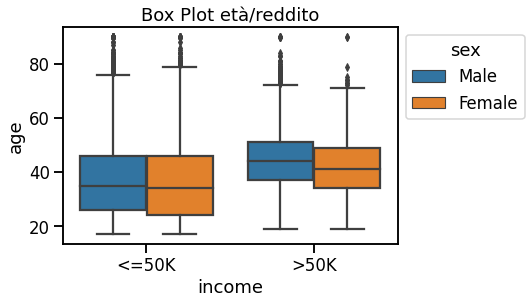

In [ ]:
ax = sns.boxplot(x = "income", y = "age", hue="sex", data=adult_train)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
plt.title('Box Plot età/reddito')
plt.show()

* i dati sono simmetrici, vista la posizione delle mediane rispetto ai quartili
* l'età degli uomini è più alta, stando sempre alle mediane osservate (ciò conferma quanto visto in fase 1, in cui le donne risultavano mediamente più giovani


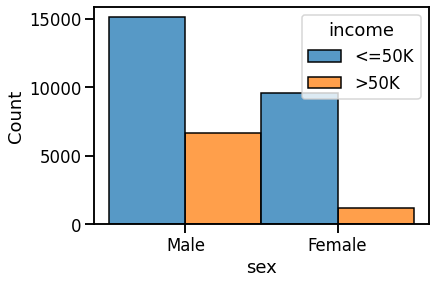

In [ ]:
sns.histplot(x="sex", hue="income", data=adult_train, multiple="dodge")
plt.show()

* a conferma di un trend presente anche tuttora, emerge che il sesso femminile è usualmente associato a minori guadagni. La quantità di uomini nel gruppo +50k è infatti decisamente più incisiva rispetto a quanto osservato tra le donne.

---



# Fase 3

---

In questa fase come richiesto uso due modelli di ML (SVM e Decision Trees) sull'intero dataset di train. In seguito proverò altri due modelli su variabili e valori selezionati. Infine confronto quanto emerso per capire la prestazione dei modelli, punti di debolezza ed eventuali margini di miglioramento.

## Data Prep



Prima di tutto **creo due nuovi dataframe** di train e test su cui processare i dati, ai quali tolgo subito la variabile *education*, visto che è già presente la corrispondente colonna codificata nel dataset di partenza *(education-num)*.


In [ ]:
train = adult_train.drop(["education"], axis=1)
test = adult_test.drop(["education"], axis=1)

Quindi procedo alla conversione delle variabili categoriche in variabili numeriche. Gli attributi "?" li codifico sempre con zero.

In [ ]:
# converto sesso in dato numerico
n_sex = {"Male": 0, "Female": 1}
train['sex'] = train['sex'].map(n_sex)
test['sex'] = test['sex'].map(n_sex)

# converto razza in dato numerico
n_race = {"Amer-Indian-Eskimo": 1, "Asian-Pac-Islander": 2, "Black": 3, "Other": 4, "White": 5}
train['race'] = train['race'].map(n_race)
test['race'] = test['race'].map(n_race)

# converto workclass in dato numerico
n_workclass = {"?": 0, "Federal-gov": 1, "Local-gov": 2, "Never-worked": 3, "Private": 4, "Self-emp-inc": 5, "Self-emp-not-inc": 6, "State-gov": 7, "Without-pay": 8}
train['workclass'] = train['workclass'].map(n_workclass)
test['workclass'] = test['workclass'].map(n_workclass)

# converto marital-status in dato numerico
n_marital = {"Divorced": 1, "Married-AF-spouse": 2, "Married-civ-spouse": 3, "Married-spouse-absent": 4, "Never-married": 5, "Separated": 6, "Widowed": 7}
train['marital-status'] = train['marital-status'].map(n_marital)
test['marital-status'] = test['marital-status'].map(n_marital)

# converto occupation in dato numerico
n_occupation = {"?": 0, "Adm-clerical": 1, "Armed-Forces": 2, "Craft-repair": 3, "Exec-managerial": 4, "Farming-fishing": 5, "Handlers-cleaners": 6, "Machine-op-inspct": 7, "Other-service": 8, "Priv-house-serv": 9, "Prof-specialty": 10, "Protective-serv": 11, "Sales": 12, "Tech-support": 13, "Transport-moving": 14}
train['occupation'] = train['occupation'].map(n_occupation)
test['occupation'] = test['occupation'].map(n_occupation)

# converto relationship in dato numerico
n_relationship = {"Husband": 1, "Not-in-family": 2, "Other-relative": 3, "Own-child": 4, "Unmarried": 5, "Wife": 6}
train['relationship'] = train['relationship'].map(n_relationship)
test['relationship'] = test['relationship'].map(n_relationship)

# converto native-country in dato numerico
n_nativecountry = {"?": 0, "Cambodia": 1, "Canada": 2, "China": 3, "Columbia": 4, "Cuba": 5, "Dominican-Republic": 6, "Ecuador": 7, "El-Salvador": 8, "England": 9, "France": 10, "Germany": 11, "Greece": 12, "Guatemala": 13, "Haiti": 14, "Holand-Netherlands": 15, "Honduras": 16, "Hong": 17, "Hungary": 18, "India": 19, "Iran": 20, "Ireland": 21, "Italy": 22, "Jamaica": 23, "Japan": 24, "Laos": 25, "Mexico": 26, "Nicaragua": 27, "Outlying-US(Guam-USVI-etc)": 28, "Peru": 29, "Philippines": 30, "Poland": 31, "Portugal": 32, "Puerto-Rico": 33, "Scotland": 34, "South": 35, "Taiwan": 36, "Thailand": 37, "Trinadad&Tobago": 38, "United-States": 39, "Vietnam": 40, "Yugoslavia": 41}
train['native-country'] = train['native-country'].map(n_nativecountry)
test['native-country'] = test['native-country'].map(n_nativecountry)

# converto income in dato numerico
n_income = {"<=50K": 0, ">50K": 1}
train['income'] = train['income'].map(n_income)
test['income'] = test['income'].map(n_income)

Per motivi di tempistica e confidenza con gli strumenti mi sono avvalso di google sheets, creando un foglio che codificasse automaticamente grazie alle formule *concatenate e join*

Il link al foglio google è https://docs.google.com/spreadsheets/d/1DaRStUCtA7u4f3rL1L1oY7lg8gFiyhZmxlEfz81iStU/edit#gid=0

ed è stato comunque inserito anche nella cartella drive condivisa del progetto 12

Infine separo la metrica (income) dai dati personali, in entrambi i dataset.

In [ ]:
# apprendimento
X_train = train.drop("income", axis=1)
Y_train = train["income"]

# test
X_test = test.drop("income", axis=1)
Y_test = test["income"]

In [ ]:
#download csv per shared drive
train.to_csv("train.csv", index=False)
test.to_csv("test.csv", index=False)

## Support-Vector Machine

Primo modello utilizzato su tutte le variabili è il classificatore SVM. 

Il tempo di esecuzione del codice di seguito è di 47 minuti.

In [ ]:
model_svm = svm.SVC(kernel='linear', C=1, random_state=0)
model_svm.fit(X_train, Y_train)

*Da segnalare che il modello SVM, oltre ad essere davvero lento, spesso quando viene lanciato genera un errore nel dataset annullando l'azione precedente (ad esempio i valori della colonna sex che diventano tutti NaN). Si riesce ad ovviare al problema rieseguendo le 4 celle precedenti a quella del modello.*

In [ ]:
Ysvm_pred = model_svm.predict(X_test)
Ysvm_pred

array([0, 0, 0, ..., 0, 1, 0])

Di seguito il test di accuratezza, che si attesta al 79,5%

In [ ]:
accuracy_score(Y_test, Ysvm_pred)

0.7957127940544193

Eseguo la matrice di confusione:

In [ ]:
confusion_matrix(Y_test, Ysvm_pred, labels=[0,1])

array([[11817,   618],
       [ 2708,  1138]])

* Persone con reddito <=50k 
 * 11817 classificate correttamente (0) 
 * 618 classificati in maniera errata (1).
* Persone con reddito >50k 
 * 2708 classificati scorrettamente (0) 
 * 1138 classificati correttamente (1).

Stampo il report di classificazione per una analisi più dettagliata:

In [ ]:
cr = classification_report(Y_test, Ysvm_pred)
print(cr) 

              precision    recall  f1-score   support

           0       0.81      0.95      0.88     12435
           1       0.65      0.30      0.41      3846

    accuracy                           0.80     16281
   macro avg       0.73      0.62      0.64     16281
weighted avg       0.77      0.80      0.77     16281



Dal report emerge che:
* il modello produce ottimi risultati in relazione al gruppo <=50k:
precisione 81% e recall 95% 
* scarsi risultati invece sui >50k: 65% di precisione e un 30% di recall

La differenza tra i due gruppi può essere dovuta alla grossa differenza tra le quantità di dati su cui il modello può confrontarsi (sono più di 12mila casi <=50k e meno di 4mila >50k). Si potrebbe comunque provare a togliere alcune variabili che ritengo poco significative (da verificare anche con correlazioni) e sperimentando configurazioni alternative del modello SVM (diverse dalla modalità lineare).

## Decision Tree

Apprendimento (tempo di esecuzione 0secondi):

In [ ]:
model_dt = tree.DecisionTreeClassifier(random_state=0) 
model_dt.fit(X_train, Y_train)

DecisionTreeClassifier(random_state=0)

In [ ]:
Ydt_pred = model_dt.predict(X_test)
Ydt_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
accuracy_score(Y_test, Ydt_pred)

0.8097782691480867

L'accuratezza del modello è del 81% circa, ovvero un punto e mezzo in più del SVM.
Segue la matrice di confusione:

In [ ]:
confusion_matrix(Y_test, Ydt_pred, labels=[0,1])

array([[10828,  1607],
       [ 1490,  2356]])


* Persone con reddito <=50k 
 * 10828 classificate correttamente (0) 
 * 1607 classificati in maniera errata (1).
* Persone con reddito >50k 
 * 1490 classificati scorrettamente (0) 
 * 2356 classificati correttamente (1).

In [ ]:
crdt = classification_report(Y_test, Ydt_pred)
print(crdt) 

              precision    recall  f1-score   support

           0       0.88      0.87      0.87     12435
           1       0.59      0.61      0.60      3846

    accuracy                           0.81     16281
   macro avg       0.74      0.74      0.74     16281
weighted avg       0.81      0.81      0.81     16281



* I risultati sul gruppo 0 (<=50k) sono anche in questo caso buoni. La precisione è maggiore rispetto al SVM (0.88 vs 0.81) mentre il tasso di recall è inferiore (0.87 vs 0.95)

* anche in questo caso la prestazione del modello sul gruppo >50k non è ottima. Tuttavia è decisamente migliore rispetto al SVM in termini di recall (0.6 vs 0.3) e leggermente meno preciso (0.59 vs 0.65)

## Light Tree DT1

Prima di elaborare un modello con variabili selezionate, provo a vedere quali sono le loro correlazioni, in particolare con *income*. 

(spunti da lezione 08 e https://stackoverflow.com/questions/17778394/list-highest-correlation-pairs-from-a-large-correlation-matrix-in-pandas)

Creo quindi una heatmap dei dati di train:

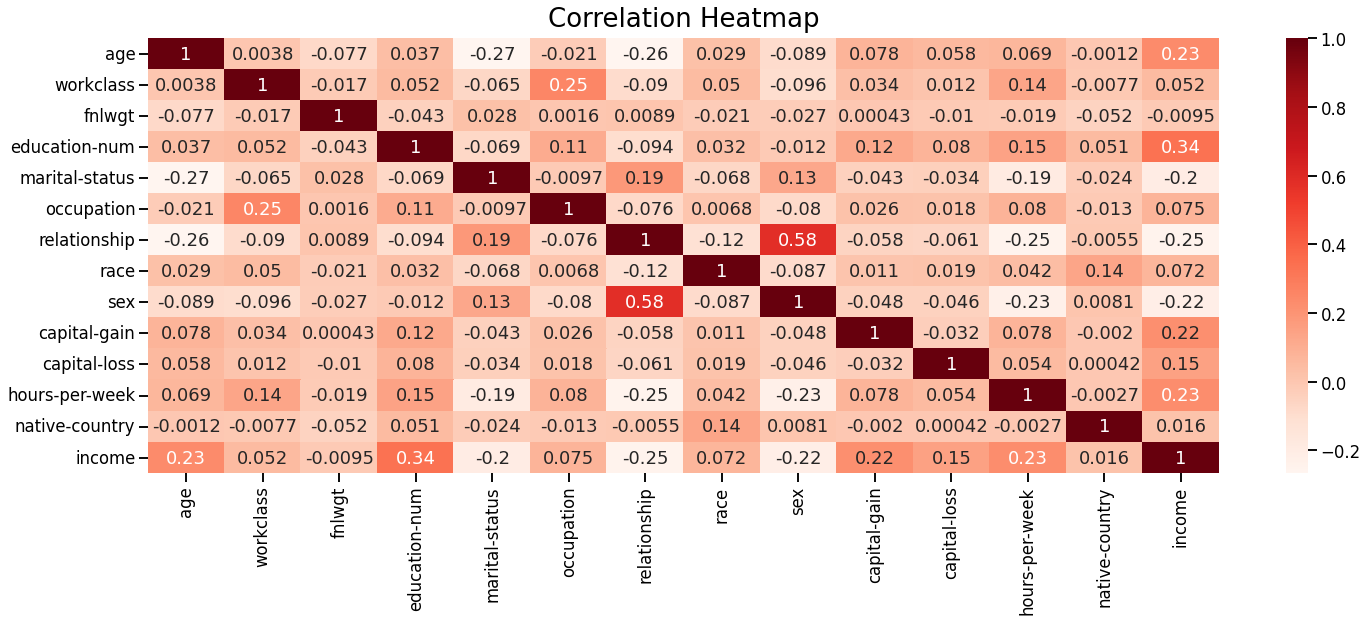

In [ ]:
train_hmap = train.corr()
plt.figure(figsize=(24,8))
sns.heatmap(train_hmap, annot=True, cmap="Reds")
plt.title('Correlation Heatmap', fontdict={'fontsize':26}, pad=12)
plt.show()

Appare evidente che tutte le variabili sono scarsamente correlate con income. L'unica relazione rilevante è quella con age, di 0.58, visibile in rosso. 

Ora ristampo il grafico rendendo visibili solamente le correlazioni positive maggiori o uguali a 0.1, le correlazioni negative minori di -0.1 e infine oscuro anche tutti i valori 1, ovvero quelli coincidenti.

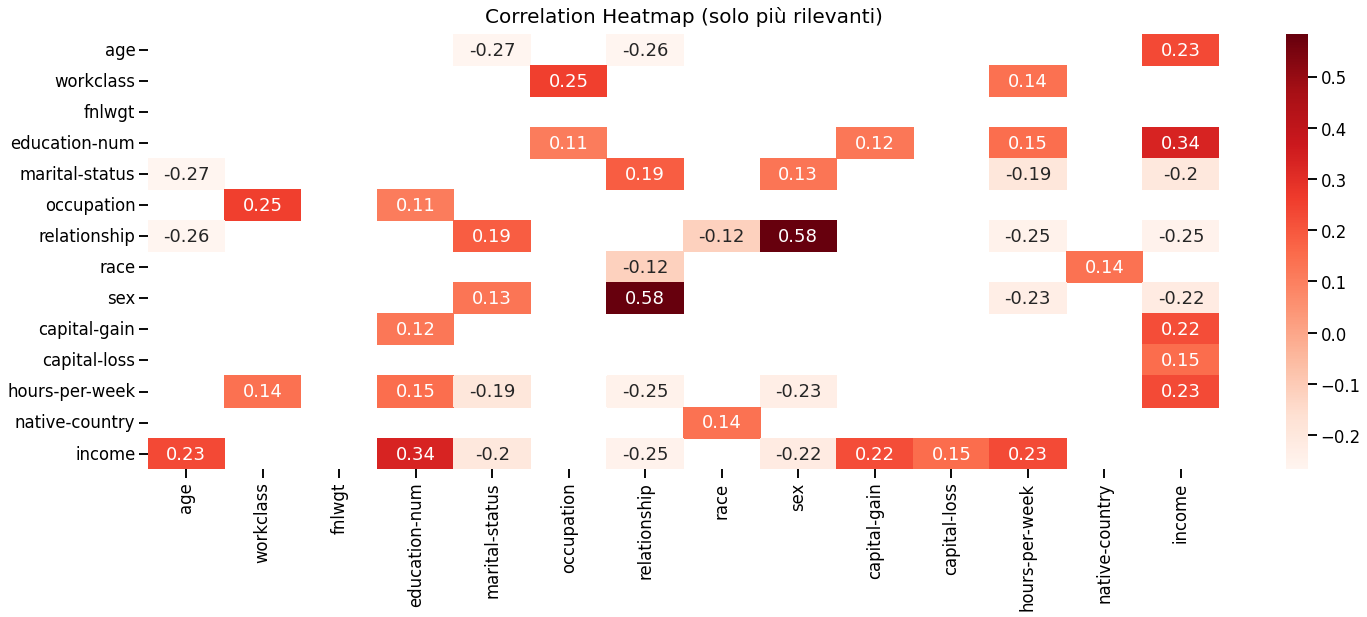

In [ ]:
oscuro = train_hmap[((train_hmap >= .1) | (train_hmap <= -.1)) & (train_hmap !=1.000)]
plt.figure(figsize=(24,8))
sns.heatmap(oscuro, annot=True, cmap="Reds")
plt.title('Correlation Heatmap (solo più rilevanti)', fontdict={'fontsize':20}, pad=12)
plt.show()


Dunque le variabili che utilizzerò per il prossimo modello sono:
* age (0.23)
*education (0.34)
*marital status (-0.2)
*relationship (-0.25)
* sex (-0.22)
* capital gain (0.22) 
* capital loss (0.15)
* hours per week (0.23)

*da escludere dunque le colonne workclass, fnlwgt, occupation, race, native country*

---



Utilizzo la selezione suggerita dalla correlazione e creo i dataframe per il terzo modello, ovvero un altro Decision Tree: **Light Tree**

In [ ]:
# apprendimento
dt1X_train = train[["age", "education-num", "marital-status", "relationship", "sex", "capital-gain", "capital-loss","hours-per-week"]]
dt1Y_train = train["income"]

# test
dt1X_test = test[["age", "education-num", "marital-status", "relationship", "sex", "capital-gain", "capital-loss","hours-per-week"]]
dt1Y_test = test["income"]

In [ ]:
#download csv per cartella condivisa drive
dt1X_train.to_csv("dt1X_train.csv", index=False)
dt1X_test.to_csv("dt1X_test.csv", index=False)
dt1Y_train.to_csv("dt1Y_train.csv", index=False)
dt1Y_test.to_csv("dt1Y_test.csv", index=False)

In [ ]:
model_dt1 = tree.DecisionTreeClassifier(random_state=0) 
model_dt1.fit(dt1X_train, dt1Y_train)

DecisionTreeClassifier(random_state=0)

*tempo di esecuzione: immediato*

In [ ]:
Ydt1_pred = model_dt1.predict(dt1X_test)
Ydt1_pred

array([0, 0, 0, ..., 1, 0, 0])

In [ ]:
confusion_matrix(dt1Y_test, Ydt1_pred, labels=[0,1])

array([[11282,  1153],
       [ 1642,  2204]])

Dalla matrice di confusione emerge che:
* Persone con reddito <=50k
 * 11282 classificate correttamente (0)
 * 1153 classificati in maniera errata (1).
* Persone con reddito >50k
 * 1642 classificati in maniera errata (0)
 * 2204 classificati correttamente (1).

In [ ]:
# report di classificazione
crdt1 = classification_report(dt1Y_test, Ydt1_pred)
print(crdt1) 

              precision    recall  f1-score   support

           0       0.87      0.91      0.89     12435
           1       0.66      0.57      0.61      3846

    accuracy                           0.83     16281
   macro avg       0.76      0.74      0.75     16281
weighted avg       0.82      0.83      0.82     16281



Rispetto al primo decision tree, la versione *light* è più accurata, registrando infatti 83% contro 81% del modello precedente
* I risultati sul gruppo 0 (<=50k) sono rimasti alti: la precisione è scesa leggermente, di 0.1, mentre il recall è salito da 0.87 a 0.91
* Per il gruppo 1 (>50k) la precisione è aumentata da 0.59 a 0.66 (superando anche la precisione del primo SVM). Per il recall invece si registra un decremento di 0.3 punti.

## Skinny Tree DT3

Con l'intento di provare ad ottimizzare le prestazioni del modello light, continuo a preferire il Decision Tree come quarto modello (visti anche i dispendiosi tempi di esecuzione dei modelli SVM).

Allora quali metriche posso escludere o modificare?


*   *marital-status* e **relationship** sono due voci simili (non uguali): così **uso solo la più correlata statisticamente a income**, ovvero la seconda. Da variabile categorica l'avevo trasformata in variabile numerica assegnando un numero diverso ad ogni status, ma dall'analisi della fase 1 era emerso che il concetto chiave era il matrimonio, il fatto di essere sposati: **la trasformo quindi in una variabile binaria** assegnando 1 ai valori marito e moglie e 0 ai rimanenti. In questo modo spero che aumenti le performance del classificatore.

*   Questa nuova variabile 0/1 permette implicitamente di dividere anche una parte (non tutto) di casi del dataset nel loro genere: un caso con valore 1 (husband) della colonna relationship è **logicamente sempre** valorizzato con il valore 0 (uomo) della colonna sex; e viceversa. **Escludo quindi la variabile sex** dall'apprendimento del modello.
* *capital gain e capital loss* sono entrambi interessanti ma **Capital gain** ha il valore di correlazione più alto (+0.7 rispetto al loss) e come visto in fase 2, incide molto sulla probabilità di avere un reddito >50k, per cui tengo solo questa metrica tra le due.
* le metriche sul lavoro *workclass e occupation* sono piuttosto deludenti in termini di correlazione al reddito. Forse potrebbe essere d'aiuto eliminare anche la terza variabile lavorativa, **hours per week.**
* **Age** è stata eliminata dai parametri per ultima, dopo tentativi di verificare cosa accadesse alle prestazioni del modello con e senza di lei. C'è da dire che anche l'età è infatti molto collegata a livello di istruzione e alla variabile matrimoniale, che spesso le fanno da filtro.

---
Di seguito le istruzioni per eseguire il modello e relative performance.
Nel paragrafo conclusivo è presente un confronto tra i 4 modelli.





In [ ]:
df3_train = adult_train[["relationship", "education-num", "capital-gain", "income"]]
df3_test = adult_test[["relationship", "education-num", "capital-gain", "income"]]

# converto relationship in dato numerico binario
nr_relationship = {"Husband": 1, "Not-in-family": 0, "Other-relative": 0, "Own-child": 0, "Unmarried": 0, "Wife": 1}
df3_train['relationship'] = df3_train['relationship'].map(nr_relationship)
df3_test['relationship'] = df3_test['relationship'].map(nr_relationship)

# converto income in dato numerico binario
nr_income = {"<=50K": 0, ">50K": 1}
df3_train['income'] = df3_train['income'].map(nr_income)
df3_test['income'] = df3_test['income'].map(nr_income)

*All'esecuzione della cella precedente compare un warning in cui il programma suggerisce di utilizzare la funziona loc anziché map. Inizialmente avevo provato anche con la funzione replace ma il warning usciva comunque.*

In [ ]:
#download csv per cartella condivisa drive
df3_train.to_csv("df3_train.csv", index=False)
df3_test.to_csv("df3_test.csv", index=False)

In [ ]:
#apprendimento
dt3X_train = df3_train.drop("income", axis=1)
dt3Y_train = df3_train["income"]

# test
dt3X_test = df3_test.drop("income", axis=1)
dt3Y_test = df3_test["income"]

In [ ]:
model_dt3 = tree.DecisionTreeClassifier(random_state=0) 
model_dt3.fit(dt3X_train, dt3Y_train)

DecisionTreeClassifier(random_state=0)

*Tempo di esecuzione: immediato*

In [ ]:
Ydt3_pred = model_dt3.predict(dt3X_test)
Ydt3_pred

array([0, 0, 0, ..., 1, 0, 1])

In [ ]:
confusion_matrix(dt3Y_test, Ydt3_pred, labels=[0,1])

array([[11830,   605],
       [ 1822,  2024]])

Dalla matrice di confusione emerge che:
* Persone con reddito <=50k
 * 11830 classificate correttamente (0) - 600 in più del modello precedente -
 * 605 classificati in maniera errata (1) - la metà del modello precedente! -
* Persone con reddito >50k
 * 1822 classificati in maniera errata (0) - quasi 200 in più di prima -
 * 2024 classificati correttamente (1) - 200 in meno -

In [ ]:
# report di classificazione
crdt3 = classification_report(dt3Y_test, Ydt3_pred)
print(crdt3) 

              precision    recall  f1-score   support

           0       0.87      0.95      0.91     12435
           1       0.77      0.53      0.63      3846

    accuracy                           0.85     16281
   macro avg       0.82      0.74      0.77     16281
weighted avg       0.84      0.85      0.84     16281



**L'accuratezza è la migliore registrata tra tutti i modelli: 85%**

* I risultati sul gruppo 0 (<=50k) sono rimasti gli stessi del modello precedente e quindi ottimi.
* Per il gruppo 1 (>50k) la precisione è aumentata molto, arrivando a 0.77 (il modello più preciso in questo gruppo). Per il recall si scende a 0.53 - inferiore al precedente ma comunque in linea con i 4 modelli -.


In [ ]:
accuracy_score(dt3Y_test, Ydt3_pred)

0.8509305325225723

In [ ]:
import graphviz

cols = list(dt3X_train.columns)
# DOT data
dot_data = tree.export_graphviz(model_dt3, out_file=None, 
                                feature_names=cols,  
                                class_names=["0","1"],
                                filled=True)

# Draw graph
graph = graphviz.Source(dot_data, format="png") 
graph

In [ ]:
import pydotplus

pydot_graph = pydotplus.graph_from_dot_data(dot_data)
pydot_graph.write_png("skinny-tree.png")

True

tabella (dizionario) con riepilogo del valore di accuracy, precision e recall dei 4 modelli per il confronto finale

# Conclusioni

In conclusione, a vedere i risultati si può affermare che l'ultimo modello, skinny tree, è il più accurato ma non è un valore troppo distante dagli altri tre, che variano tra 80-83%.

Sulla classe negativa 0, ovvero l'individuazione di chi percepisce meno di 50k, tutti i modelli hanno buoni risultati: la precisione dei DT si aggira tra 87-88% mentre quella del SVM è inferiore, 81%.
Per il recall i dati sono ancora migliori e osserviamo valori 87-91% per i DT e un 95% per l'SVM, che riconosce quasi perfettamente quindi i falsi negativi.

Sulla classe positiva 1, le persone con reddito oltre 50k, i dati sono meno incoraggianti. I primi tre modelli hanno un precisione tra 61-66% e il quarto modello DT è decisamente più preciso: 77%. I tassi di recall sono pessimi per tutti i modelli (nessuno supera il 60%), in particolare il modello SVM registra un misero 30%.

In generale, a livello di scelta, penso che la migliore opzione sarebbe l'ultimo modello visto che registra mediamente le prestazioni migliori e, in questo senso, l'analisi dei dati sulle metriche da selezionare/ottimizzare ha dato i suoi frutti. Al contrario escluderei totalmente l'SVM a causa dei tempi di esecuzione troppo lunghi.

Seguono alcune riflessioni emerse durante il lavoro.

---






In relazione agli aspetti tecnici del progetto e alle prospettive di miglioramento:
* dall'analisi dei dati mi era sembrato che le ore lavorate (e in parte anche gli investimenti) fossero elementi di poco conto ma sono stato smentito dalla correlazione statistica e dalla heatmap. Avrei puntato di più sulle variabili professionali, del lavoro, che invece non sono risultate determinanti. Confermata invece l'importanza della variabile matrimoniale e dell'istruzione, le più importanti sicuramente.
* capire se i tempi così lunghi del SVM sono normali ed eventualmente dandogli in pasto un dataset molto ottimizzato, similmente all'ultimo utilizzato.
* capire a fondo i motivi delle prestazioni così basse sul gruppo positivo (nonostante fosse la minor parte della popolazione)
* ottimizzare il codice e razionalizzare le sequenze di creazione var. e df, così da risultare meno confusionario e accorciare il progetto per renderlo più godibile
* risolvere i problemi riscontrati dagli warning
* utilizzare il random forest al posto del decision tree
* trattare diversamente i valori "?" nel dataset, valorizzandoli con la media di colonna 
* cosa sarebbe successo togliendo i duplicati? Avrebbe distorto la rappresentatività dei casi o avrebbe aiutato il classificatore a svolgere meglio il suo lavoro?



Il recap delle prestazioni dei 4 modelli è visibile al link https://docs.google.com/spreadsheets/d/1Qupg9zk6PY9zYGTDfCUpKnyIesLWOLZ6hDk3umpdODY/edit#gid=0

Ed è presente anche nella cartella drive condivisa.

Applicata una formula di formattazione condizionale per evidenziare i valori migliori e quelli meno.

